In [236]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [237]:
print(tf.__version__)

2.17.0


In [238]:
a = tf.constant(2)
print(tf.rank(a))
print(a)

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)


In [239]:
b = tf.constant([2,3])
print(tf.rank(b))
print(b)

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor([2 3], shape=(2,), dtype=int32)


In [240]:
c = tf.constant([[2,3],
                 [6,7]])
print(tf.rank(c))
print(c)

tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(
[[2 3]
 [6 7]], shape=(2, 2), dtype=int32)


In [241]:
d = tf.constant(['Hello'])
print(tf.rank(d))
print(d)

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor([b'Hello'], shape=(1,), dtype=string)


In [242]:
rand = tf.random.uniform([1],0,1)
print(rand.shape)
print(rand)

(1,)
tf.Tensor([0.21828926], shape=(1,), dtype=float32)


In [243]:
rand2 = tf.random.normal([1,2],0,1)
print(rand2.shape)
print(rand2)

(1, 2)
tf.Tensor([[1.425834  1.4995534]], shape=(1, 2), dtype=float32)


In [244]:
rand3 = tf.random.normal(shape=(3,2),mean=0,stddev=1)
print(rand3.shape)
print(rand3)

(3, 2)
tf.Tensor(
[[-0.12085921 -1.4510431 ]
 [-1.096412    0.9497141 ]
 [ 0.14646924  1.6441822 ]], shape=(3, 2), dtype=float32)


## 즉시 실행 모드 (Eager Mode) 지원
즉시 실행모드를 통해 텐서플로우를 파이썬처럼 사용할 수 있음


In [245]:
a = tf.constant(3)
b = tf.constant(2)

In [246]:
print(tf.add(a,b))
print(a+b)

tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)


In [247]:
print(tf.subtract(a,b))
print(a-b)

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)


In [248]:
print(tf.multiply(a,b))
print(a*b)

tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)


In [249]:
print(tf.divide(a,b))
print(a/b)

tf.Tensor(1.5, shape=(), dtype=float64)
tf.Tensor(1.5, shape=(), dtype=float64)


텐서 플로우 <-> 넘파이

In [250]:
c = tf.add(a,b).numpy()
print(type(c))

<class 'numpy.int32'>


In [251]:
c_squre = np.square(c,dtype=np.float32)
c_tensor =tf.convert_to_tensor(c_squre)
print(c_tensor)
print(type(c_tensor))

tf.Tensor(25.0, shape=(), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [252]:
t = tf.constant([[1.,2.,3.],
                 [4.,5.,6.]])
print(t.shape)
print(t.dtype)

(2, 3)
<dtype: 'float32'>


In [253]:
print(tf.transpose(t))

tf.Tensor(
[[1. 4.]
 [2. 5.]
 [3. 6.]], shape=(3, 2), dtype=float32)


In [254]:
print(t[:,1:])

tf.Tensor(
[[2. 3.]
 [5. 6.]], shape=(2, 2), dtype=float32)


In [255]:
t[...,1,tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

In [256]:
t+10

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [257]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [258]:
t @ tf.transpose(t)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

tensorflow는 타입은 맞춰야 계산 가능


In [259]:
a = tf.constant(2)

b = tf.constant(2.)

In [260]:
t = tf.constant(30.,dtype=tf.float64)
t2 = tf.constant(4.)
print(t2 + tf.cast(t,tf.float32))

tf.Tensor(34.0, shape=(), dtype=float32)


In [261]:
import timeit

In [262]:
@tf.function
def my_function(x) :
    return x**2 - 10*x + 3

print(my_function(2))
print(my_function(tf.constant(2)))

tf.Tensor(-13, shape=(), dtype=int32)
tf.Tensor(-13, shape=(), dtype=int32)


In [263]:
def my_function_(x) :
    return x**2 - 10*x + 3
print(my_function_(3))
print(my_function_(tf.constant(3)))

-18
tf.Tensor(-18, shape=(), dtype=int32)


In [264]:
tf_my_func = tf.function(my_function_)
print(tf_my_func)
print(tf_my_func(2))


tf.Tensor(-13, shape=(), dtype=int32)


In [265]:
tf_my_func.python_function(2)

-13

In [266]:
def function_to_get_faster(x,y,b) :
    x = tf.matmul(x,y)
    x = x+b
    return x
a_function=tf.function(function_to_get_faster)

x = tf.constant([[1.0,2.0]])
y = tf.constant([[2.0],[3.0]])
b = tf.constant(4.0)

a_function(x,y,b).numpy()


array([[12.]], dtype=float32)

In [267]:
def inner_function(x,y,b) :
    x = tf.matmul(x,y)
    x = x+b
    return x

@tf.function
def outer_function(x) :
    y = tf.constant([[2.0],[3.0]])
    b = tf.constant(4.0)
    return inner_function(x,y,b)

outer_function(tf.constant([[1.0,2.0]])).numpy()

array([[12.]], dtype=float32)

In [268]:
print(tf.autograph.to_code(my_function.python_function))

def tf__my_function(x):
    with ag__.FunctionScope('my_function', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()
        try:
            do_return = True
            retval_ = ag__.ld(x) ** 2 - 10 * ag__.ld(x) + 3
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [269]:
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Flatten, Input
from tensorflow.keras.models import Sequential

In [270]:
model = Sequential()

model.add(Dense(32,input_shape=(64,),activation='relu'))

model.add(Dense(16,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [271]:
Dense(10,activation='softmax')

<Dense name=dense_53, built=False>

In [272]:
Dense(10,activation='relu',name='Dense Layer')

<Dense name=Dense Layer, built=False>

In [273]:
Dense(10,kernel_initializer='he_normal',name='Dense Layer')


<Dense name=Dense Layer, built=False>

In [274]:
dense = Dense(10,activation='relu',name='Dense Layer')
Activation(dense)

<Activation name=activation_5, built=False>

In [275]:
Flatten(input_shape=(128,3,2,2))

<Flatten name=flatten_5, built=False>

In [276]:
Input(shape=(28,28),dtype=tf.float32)


<KerasTensor shape=(None, 28, 28), dtype=float32, sparse=False, name=keras_tensor_112>

In [277]:
Input(shape=(8,),dtype=tf.int32)

<KerasTensor shape=(None, 8), dtype=int32, sparse=False, name=keras_tensor_113>

Sequential()

모델이 순차적인 구조로 진행할 때 사용

간단한 방법 

Sequential 객체 생성 후 add()를 이용한 방법

Sequential 인자에 한 번에 추가 방법

복잡한 모델을 구성할 수 없다

In [278]:
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model

In [279]:
model = Sequential()
model.add(Input(shape=(28,28)))
model.add(Dense(300,activation='relu'))
model.add(Dense(100,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 28, 300)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 28, 100)        │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 28, 10)         │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,810 (155.51 KB)

 Trainable params: 39,810 (155.51 KB)

 Non-trainable params: 0 (0.00 B)

In [280]:
from tensorflow.keras.layers import Concatenate

input_layer = Input(shape=(28,28))
hidden1 = Dense(100,activation='relu')(input_layer)
hidden2 = Dense(30,activation='relu')(hidden1)
concat = Concatenate()([input_layer,hidden2])
output = Dense(1)(concat)

model= Model(inputs=[input_layer],outputs=[output])
model.summary()

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 28, 100)   │      2,900 │ input_layer_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 28, 30)    │      3,030 │ dense_57[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 28, 58)    │          0 │ input_layer_29[0… │
│ (Concatenate)       │                   │            │ dense_58[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 28, 1)     │         59 │ concatenate_5[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,989 (23.39 KB)

 Trainable params: 5,989 (23.39 KB)

 Non-trainable params: 0 (0.00 B)

In [281]:
plot_model(model)

AttributeError: module 'pydot' has no attribute 'InvocationException'

In [ ]:
input_1 = Input(shape=(10,10),name='input_1')
input_2 = Input(shape=(10,28),name='input_2')

hidden1 = Dense(100,activation='relu')(input_2)
hidden2 = Dense(10,activation='relu')(hidden1)
concat = Concatenate()([input_1,hidden2])
output = Dense(1,activation='sigmoid',name='output')(concat)

model = Model(inputs=[input_1,input_2],outputs=[output])
model.summary()


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 10, 100)   │      2,900 │ input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 10, 20)    │          0 │ input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 10, 1)     │         21 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,931 (15.36 KB)

 Trainable params: 3,931 (15.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_= Input(shape=(10,10),name='input_1')

hidden1 = Dense(100,activation='relu')(input_)
hidden2 = Dense(10,activation='relu')(hidden1)

output = Dense(1,activation='sigmoid',name='main_output')(hidden2)
sub_out = Dense(1,name='sum_output')(hidden2)

model = Model(inputs=[input_],outputs=[output,sub_out])
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 10, 100)   │      1,100 │ input_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 10, 1)     │         11 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum_output (Dense)  │ (None, 10, 1)     │         11 │ dense_34[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,132 (8.33 KB)

 Trainable params: 2,132 (8.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [ ]:
input_1 = Input(shape=(10,10),name='input_1')
input_2 = Input(shape=(10,28),name='input_2')

hidden1 = Dense(100,activation='relu')(input_2)
hidden2 = Dense(10,activation='relu')(hidden1)

concat = Concatenate()([input_1,hidden2])
output = Dense(1,activation='sigmoid',name='main_output')(concat)
sub_out = Dense(1,name='sub_output')(hidden2)

model = Model(inputs=[input_1,input_2],outputs=[output,sub_out])

model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 10, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 10, 100)   │      2,900 │ input_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 10, 10)    │      1,010 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 10, 20)    │          0 │ input_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_output (Dense) │ (None, 10, 1)     │         21 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sub_output (Dense)  │ (None, 10, 1)     │         11 │ dense_40[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,942 (15.40 KB)

 Trainable params: 3,942 (15.40 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class MyModel(Model) :
    def __init__(self,units=30,activation='relu',**kwargs) :
        super(MyModel,self).__init__(**kwargs)
        self.dense_layer1 = Dense(300,activation=activation)
        self.dense_layer2 = Dense(100,activation=activation)
        self.dense_layer3 = Dense(units,activation=activation)
        self.output_layer = Dense(10,activation='softmax')

    def call(self,inputs) :
        x = self.dense_layer1(inputs)
        x = self.dense_layer2(x)
        x = self.dense_layer3(x)
        x = self.output_layer(x)
        return x


In [ ]:
inputs = Input(shape=(28,28,1))
x = Flatten(input_shape=(28,28,1))(input)
x = Dense(300,activation='relu')(x)
x = Dense(100,activation='relu')(x)
x = Dense(10,activation='softmax')(x)

model = Model(inputs=inputs,outputs=x)
model.summary()

C:\Users\kjb00\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 10, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 100)       │          0 │ input_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 300)       │     30,300 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 100)       │     30,100 │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 10)        │      1,010 │ dense_45[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,410 (239.88 KB)

 Trainable params: 61,410 (239.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers

[<InputLayer name=input_1, built=True>,
 <Flatten name=flatten_2, built=True>,
 <Dense name=dense_44, built=True>,
 <Dense name=dense_45, built=True>,
 <InputLayer name=input_layer_12, built=True>,
 <Dense name=dense_46, built=True>]

In [ ]:
hidden_2 = model.layers[2]
hidden_2.name

'dense_44'

In [ ]:
model.get_layer('dense_44') is hidden_2

True

In [ ]:
weights, biases = hidden_2.get_weights()

print(weights.shape)
print(biases.shape)

(100, 300)
(300,)


In [ ]:
print(weights)

[[ 0.09766129 -0.08833353 -0.08314547 ... -0.07733209  0.0481027
   0.10800596]
 [ 0.04107779  0.01629706 -0.00092667 ...  0.07402631  0.07977054
  -0.01336683]
 [ 0.12216888 -0.03528254  0.05934022 ...  0.02831347  0.02900309
  -0.06403842]
 ...
 [ 0.05650573 -0.09529629  0.12216958 ...  0.01784348  0.12012205
  -0.03533226]
 [-0.07785375  0.02981988  0.09413642 ...  0.01857439 -0.10449578
   0.08599234]
 [ 0.11722519 -0.08500819  0.03707444 ... -0.09870634 -0.01347972
  -0.0820729 ]]


In [ ]:
print(biases)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accurary'])

In [295]:
import tensorflow as tf
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Sequential
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.utils import to_categorical, plot_model

from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

In [283]:
tf.random.set_seed(111)

(x_train_full,y_train_full), (x_test,y_test) = load_data(path='mnist.npz')

x_train,x_val,y_train,y_val = train_test_split(x_train_full,y_train_full,
                                               test_size=0.3,
                                               random_state=111)

In [286]:
num_x_train = (x_train.shape[0])
num_x_val = (x_val.shape[0])
num_x_test = (x_test.shape[0])

print(x_train_full.shape,y_train_full.shape)
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)
print(x_test.shape,y_test.shape)


(60000, 28, 28) (60000,)
(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)
(10000, 28, 28) (10000,)


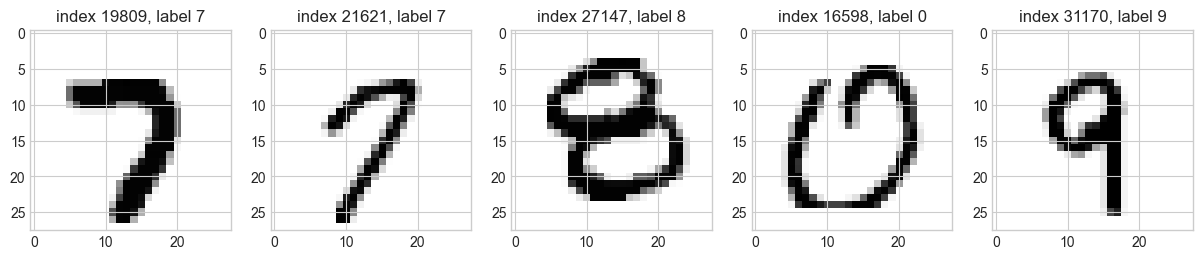

In [285]:
num_sample = 5
random_idxs = np.random.randint(60000,size=num_sample)

plt.figure(figsize=(15,3))
for i,idx in enumerate(random_idxs) :
    img = x_train_full[idx,:]
    label = y_train_full[idx]

    plt.subplot(1,len(random_idxs),i+1)
    plt.imshow(img)
    plt.title(f'index {idx}, label {label}')

In [291]:
x_train = x_train/255 # 0 ~ 1 사이의 값을 가진다. -> 픽셀 값은 0~255 사이의 값을 가지기 때문에
x_val = x_val/255
x_test = x_test/255

y_train = to_categorical(y_train) # 0~9 사이의 숫자들을 one-hot-encoding 적용
y_val =to_categorical(y_val)
y_test =to_categorical(y_test)



In [293]:
model = Sequential([Input(shape=(28,28),name='input'),
                    Flatten(input_shape=(28,28),name='flatten'),
                    Dense(100,activation='relu',name='dense1'),
                    Dense(64,activation='relu',name='dense2'),
                    Dense(32,activation='relu',name='dense3'),
                    Dense(10,activation='softmax',name='output')])
model.summary()

C:\Users\kjb00\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,374 (341.30 KB)

 Trainable params: 87,374 (341.30 KB)

 Non-trainable params: 0 (0.00 B)

In [296]:
model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [297]:
history = model.fit(x_train,y_train,
                    epochs=50,
                    batch_size=128,
                    validation_data=(x_val,y_val))

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3392 - loss: 2.0284 - val_accuracy: 0.7882 - val_loss: 0.9155
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.7538 - val_accuracy: 0.8639 - val_loss: 0.4921
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8718 - loss: 0.4701 - val_accuracy: 0.8831 - val_loss: 0.4003
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8905 - loss: 0.3927 - val_accuracy: 0.8950 - val_loss: 0.3578
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8999 - loss: 0.3527 - val_accuracy: 0.9009 - val_loss: 0.3314
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9071 - loss: 0.3261 - val_accuracy: 0.9078 - val_loss: 0.3118
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9124 - loss: 0.3055 - val_accuracy: 0.9117 - val_loss: 0.2965
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9165 - loss: 0.2887 - val_accuracy: 0.

In [300]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [308]:
plt.style.use(['seaborn-v0_8-whitegrid'])

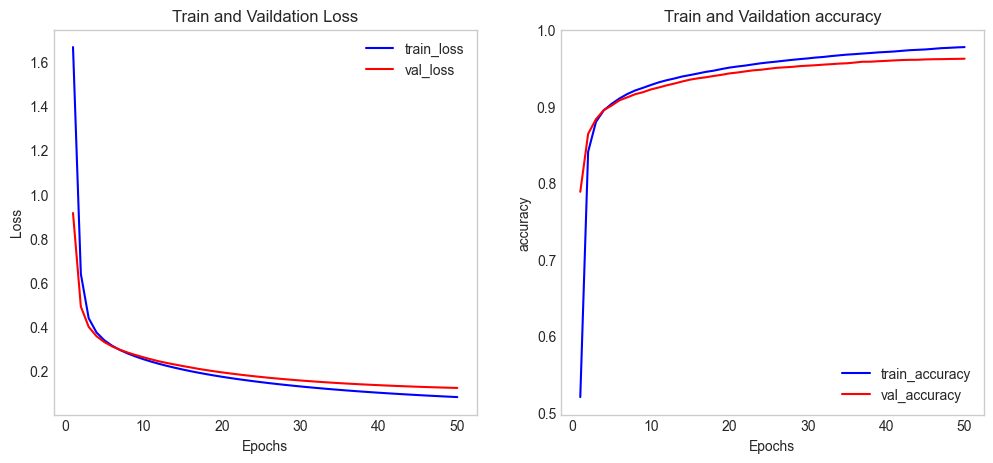

In [309]:
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1,len(loss)+1)
fig = plt.figure(figsize=(12,5))
ax1 =fig.add_subplot(1,2,1)
ax1.plot(epochs,loss,color='blue',label='train_loss')
ax1.plot(epochs,val_loss,color='red',label='val_loss')
ax1.set_title('Train and Vaildation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()


accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1,len(loss)+1)
ax2 =fig.add_subplot(1,2,2)
ax2.plot(epochs,accuracy,color='blue',label='train_accuracy')
ax2.plot(epochs,val_accuracy,color='red',label='val_accuracy')
ax2.set_title('Train and Vaildation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('accuracy')
ax2.grid()
ax2.legend()

plt.show()

In [310]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.9602 - loss: 0.1302


[0.11572661995887756, 0.9646000266075134]

In [313]:
pred_ys = model.predict(x_test)
print(pred_ys.shape)
np.set_printoptions(precision=7)
print(pred_ys[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step
(10000, 10)
[4.6280020e-05 6.5476189e-07 2.1576841e-04 6.7329290e-04 1.0595697e-05
 3.0425028e-06 1.2125495e-10 9.9826992e-01 1.4025077e-06 7.7899144e-04]


Text(0.5, 1.0, 'Predicted label 7')

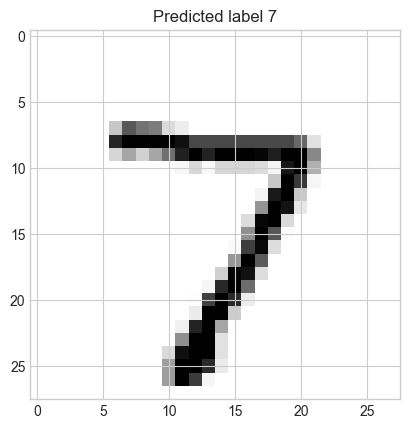

In [314]:
arg_pred_Y = np.argmax(pred_ys,axis=1)
plt.imshow(x_test[0])
plt.title(f'Predicted label {arg_pred_Y[0]}')

Text(67.25, 0.5, 'True label')

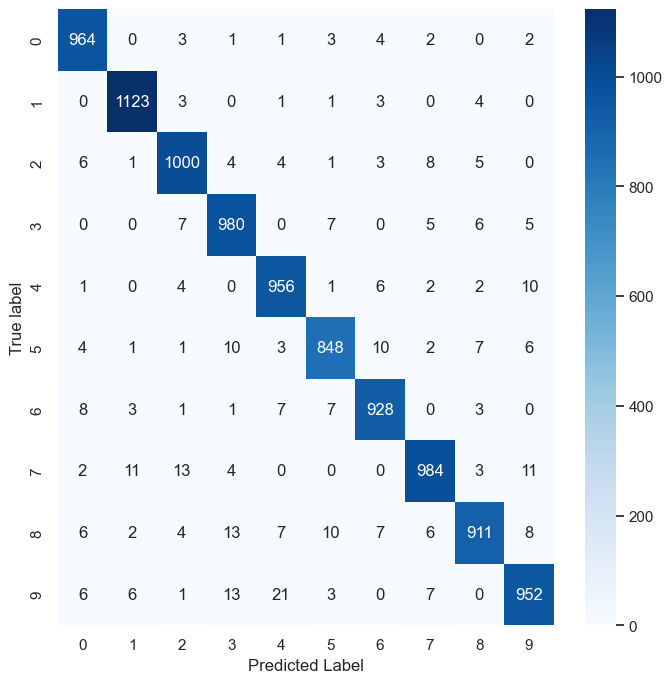

In [316]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
sns.set(style='white')

plt.figure(figsize=(8,8))
cm = confusion_matrix(np.argmax(y_test,axis=1),np.argmax(pred_ys,axis=1))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True label')

In [317]:
print(classification_report(np.argmax(y_test,axis=1),np.argmax(pred_ys,axis=1)))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.96      0.95      0.96       892
           6       0.97      0.97      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.94      0.95       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



저장 및 복원

In [319]:
model.save('minst_model.keras')

In [320]:
loaded_model = models.load_model('minst_model.h5')
loaded_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,376 (341.32 KB)

 Trainable params: 87,374 (341.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [321]:
pred_ys2 = loaded_model.predict(x_test)
print(pred_ys2.shape)



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step
(10000, 10)


콜백 (Callbacks)

ModelCheckpoint , EarlyStopping, LearningRateSchduler, TensorBoard

In [325]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,LearningRateScheduler,TensorBoard

In [327]:
check_point_cb = ModelCheckpoint('mnist_model.keras')
history = model.fit(x_train,y_train,epochs=10,
                    callbacks = [check_point_cb])

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9744 - loss: 0.0882
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9768 - loss: 0.0828
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.9786 - loss: 0.0769
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9804 - loss: 0.0716
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9821 - loss: 0.0666
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9838 - loss: 0.0622
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9848 - loss: 0.0580
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9862 - loss: 0.0542
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9869 - loss: 0.0506
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9878 - loss: 0.0472


In [330]:
check_point_cb = ModelCheckpoint('mnist_model.keras',save_best_only=True)
history = model.fit(x_train,y_train,epochs=10,
                    validation_data =(x_val,y_val),
                    callbacks = [check_point_cb])

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9966 - loss: 0.0210 - val_accuracy: 0.9692 - val_loss: 0.1161
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9969 - loss: 0.0194 - val_accuracy: 0.9687 - val_loss: 0.1168
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9973 - loss: 0.0179 - val_accuracy: 0.9687 - val_loss: 0.1173
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9974 - loss: 0.0166 - val_accuracy: 0.9688 - val_loss: 0.1180
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9977 - loss: 0.0153 - val_accuracy: 0.9692 - val_loss: 0.1188
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9980 - loss: 0.0142 - val_accuracy: 0.9695 - val_loss: 0.1196
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9982 - loss: 0.0131 - val_accuracy: 0.9694 - val_loss: 0.1204
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9984 - loss: 0.0122 - 

In [332]:
check_point_cb = ModelCheckpoint('mnist_model.keras',save_best_only=True)
early_stopping = EarlyStopping(patience=3,monitor='val_loss',
                               restore_best_weights=True)
history = model.fit(x_train,y_train,epochs=10,
                    validation_data =(x_val,y_val),
                    callbacks = [check_point_cb,early_stopping])

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 0.9711 - val_loss: 0.1316
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.9711 - val_loss: 0.1321
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9711 - val_loss: 0.1328
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9713 - val_loss: 0.1334


In [342]:
def scheduler(epochs,learning_rate) :
    if epochs < 10 :
        return float(learning_rate)
    else :
        return float(learning_rate * tf.math.exp(-0.1))
    

In [343]:
round(model.optimizer.learning_rate.numpy(),5)

0.01

In [344]:
lr_scheduler_cb = LearningRateScheduler(scheduler)
history = model.fit(x_train,y_train,
                    epochs=15,
                    callbacks = [lr_scheduler_cb],verbose=0)
round(model.optimizer.learning_rate.numpy(),5)

0.00607

In [345]:
log_dir = './logs'
tensor_board_cb = [TensorBoard(log_dir=log_dir,histogram_freq=1,write_graph=True,write_images=True)]
model.fit(x_train,y_train,batch_size=32,validation_data=(x_val,y_val),
          epochs=30,callbacks=tensor_board_cb)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9717 - val_loss: 0.1442
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9717 - val_loss: 0.1444
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9718 - val_loss: 0.1446
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9718 - val_loss: 0.1448
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9718 - val_loss: 0.1451
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9718 - val_loss: 0.1453
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9719 - val_loss: 0.1455
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 1.0000 - loss: 0.0014 - 

In [8]:
from tensorflow.keras.datasets import imdb
import numpy as np

(train_data,train_labels) , (test_data,test_labels) = imdb.load_data(num_words=10000)

In [9]:
def vectorize_seq(seqs,dim=10000) :
    results = np.zeros((len(seqs),dim))
    for i , seq in enumerate(seqs) :
        results[i,seq] = 1.
    return results

x_train =vectorize_seq(train_data)
x_test = vectorize_seq(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [12]:
model = Sequential([Dense(16,activation='relu',input_shape=(10000,),name='input'),
                    Dense(16,activation='relu',name='hidden'),
                    Dense(1,activation='sigmoid',name='output')])

model.compile(optimizer='rmsprop',
              loss = 'binary_crossentropy',
              metrics=['acc'])
model.summary()

C:\Users\kjb00\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_hist = model.fit(x_train,y_train,
                       epochs=20,
                       batch_size=512,
                       validation_data=(x_test,y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - acc: 0.7483 - loss: 0.5850 - val_acc: 0.8744 - val_loss: 0.3747
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.8915 - loss: 0.3192 - val_acc: 0.8884 - val_loss: 0.2961
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9173 - loss: 0.2368 - val_acc: 0.8894 - val_loss: 0.2797
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9340 - loss: 0.1943 - val_acc: 0.8866 - val_loss: 0.2828
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9402 - loss: 0.1702 - val_acc: 0.8836 - val_loss: 0.2908
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9476 - loss: 0.1558 - val_acc: 0.8823 - val_loss: 0.3023
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9566 - loss: 0.1323 - val_acc: 0.8723 - val_loss: 0.3397
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9603 - loss: 0.1188 - val_acc: 0.8768 - val_loss: 0.3331
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9637 - loss

In [14]:
import matplotlib.pyplot as plt

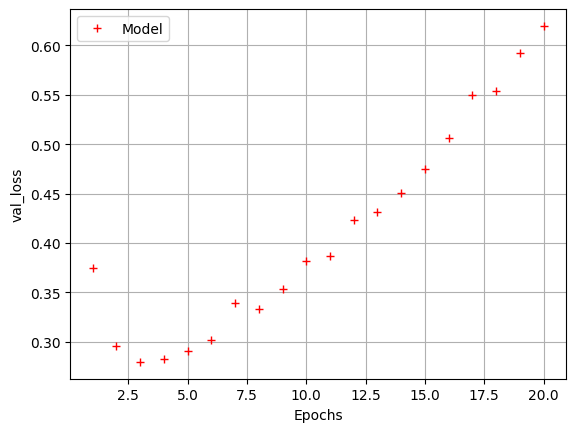

In [17]:
epochs = range(1,21)
model_val_loss = model_hist.history['val_loss']
plt.plot(epochs,model_val_loss,'r+',label='Model')
plt.xlabel('Epochs')
plt.ylabel('val_loss')
plt.legend()
plt.grid()
plt.show()

In [20]:
model_s = Sequential([Dense(7,activation='relu',input_shape=(10000,),name='input'),
                      Dense(7,activation='relu',name='hidden'),
                      Dense(1,activation='sigmoid',name='output')])
model_s.compile(optimizer='rmsprop',
                loss ='binary_crossentropy',
                metrics=['acc'])
model_s.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 7)              │        70,007 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,071 (273.71 KB)

 Trainable params: 70,071 (273.71 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_s_hist = model_s.fit(x_train,y_train,
                           epochs=20,
                           batch_size=512,
                           validation_data=(x_test,y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.6621 - loss: 0.6231 - val_acc: 0.8604 - val_loss: 0.4289
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8916 - loss: 0.3670 - val_acc: 0.8836 - val_loss: 0.3281
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9154 - loss: 0.2630 - val_acc: 0.8898 - val_loss: 0.2907
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9297 - loss: 0.2151 - val_acc: 0.8909 - val_loss: 0.2788
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9392 - loss: 0.1830 - val_acc: 0.8892 - val_loss: 0.2801
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9468 - loss: 0.1643 - val_acc: 0.8818 - val_loss: 0.2949
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9518 - loss: 0.1451 - val_acc: 0.8839 - val_loss: 0.2955
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9579 - loss: 0.1333 - val_acc: 0.8817 - val_loss: 0.3073
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9605 - loss:

In [23]:
model_s_hist.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

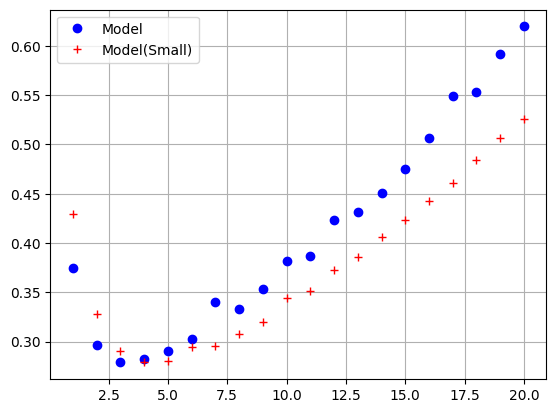

In [33]:
model_epochs = range(1,21)
model_s_dict = model_s_hist.history['val_loss']
plt.plot(epochs,model_val_loss,'bo',label="Model")
plt.plot(model_epochs,model_s_dict,'r+',label="Model(Small)")
plt.legend()
plt.grid()


In [31]:
model_b = Sequential([Dense(1024,activation='relu',input_shape=(10000,),name='input'),
                      Dense(1024,activation='relu',name='hidden'),
                      Dense(1,activation='sigmoid',name='output')])
model_b.compile(optimizer='rmsprop',
                loss ='binary_crossentropy',
                metrics=['acc'])
model_b.summary()

C:\Users\kjb00\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 1024)           │    10,241,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,291,649 (43.07 MB)

 Trainable params: 11,291,649 (43.07 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_b_hist = model_b.fit(x_train,y_train,
                           epochs=20,
                           batch_size=512,
                           validation_data=(x_test,y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - acc: 0.6422 - loss: 0.6415 - val_acc: 0.8354 - val_loss: 0.3770
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - acc: 0.8834 - loss: 0.2854 - val_acc: 0.8805 - val_loss: 0.2832
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - acc: 0.9227 - loss: 0.2061 - val_acc: 0.8284 - val_loss: 0.4523
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - acc: 0.9294 - loss: 0.1741 - val_acc: 0.8515 - val_loss: 0.3715
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - acc: 0.9570 - loss: 0.1178 - val_acc: 0.8847 - val_loss: 0.3234
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - acc: 0.9762 - loss: 0.0733 - val_acc: 0.8823 - val_loss: 0.3499
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - acc: 0.9871 - loss: 0.0473 - val_acc: 0.8130 - val_loss: 0.6960
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - acc: 0.9771 - loss: 0.0565 - val_acc: 0.8797 - val_loss: 0.3698
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - ac

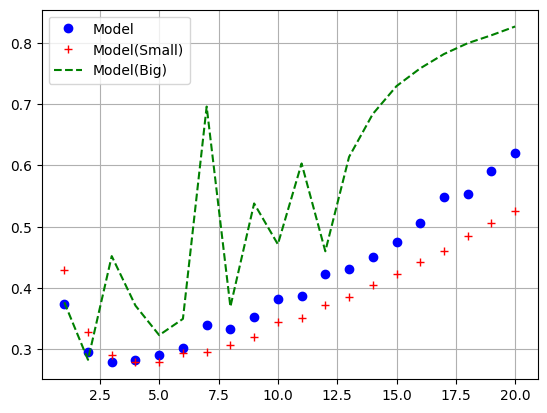

In [34]:
model_b_dict = model_b_hist.history['val_loss']
plt.plot(epochs,model_val_loss,'bo',label="Model")
plt.plot(model_epochs,model_s_dict,'r+',label="Model(Small)")
plt.plot(epochs,model_b_dict,'g--',label='Model(Big)')
plt.legend()
plt.grid()

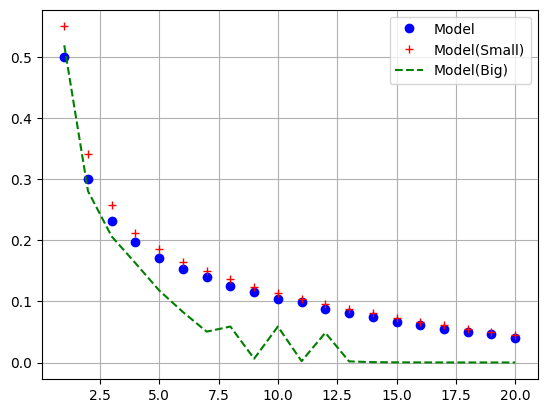

In [36]:
model_train_loss = model_hist.history['loss']
model_s_train_loss = model_s_hist.history['loss']
model_b_train_loss = model_b_hist.history['loss']

plt.plot(epochs,model_train_loss,'bo',label="Model")
plt.plot(epochs,model_s_train_loss,'r+',label="Model(Small)")
plt.plot(epochs,model_b_train_loss,'g--',label='Model(Big)')
plt.legend()
plt.grid()
 

In [2]:
from tensorflow.keras.optimizers import SGD 

optimizer = SGD(learning_rate=0.001,momentum=0.9)


In [3]:
optimizer = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)

In [4]:
from tensorflow.keras.optimizers import Adagrad

optimizer=Adagrad(learning_rate=0.001)

In [5]:
from tensorflow.keras.optimizers import RMSprop

optimizer = RMSprop(learning_rate=0.001,rho=0.9)

In [7]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)

In [11]:
import numpy as np
def sigmoid(x) :
    return 1 / (1+np.exp(-x))

x = np.random.randn(1000,50)
nodes = 50
hidden_layers = 6
activation_values = {}

for i in range(hidden_layers) :
    if i !=0 :
        x = activation_values[i-1]
    
    w = np.zeros((nodes,nodes))
    a = np.dot(x,w)
    z = sigmoid(a)
    activation_values[i] = z

TypeError: object of type 'builtin_function_or_method' has no len()

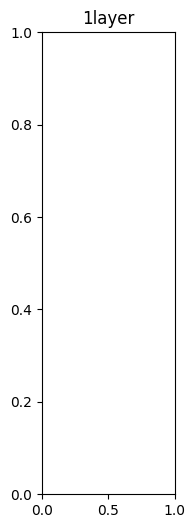

In [18]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Flatten

plt.figure(figsize=(12,6))
for i , a in activation_values.items() :
    plt.subplot(1,len(activation_values),i+1)
    plt.title(str(i+1) + 'layer')
    plt.hist(a.flatten,50,range=(0,1))
    plt.subplots_adjust(wspace=0.5,hspace=0.5)